# ANALISAR DADOS AO LONGO DO TEMPO

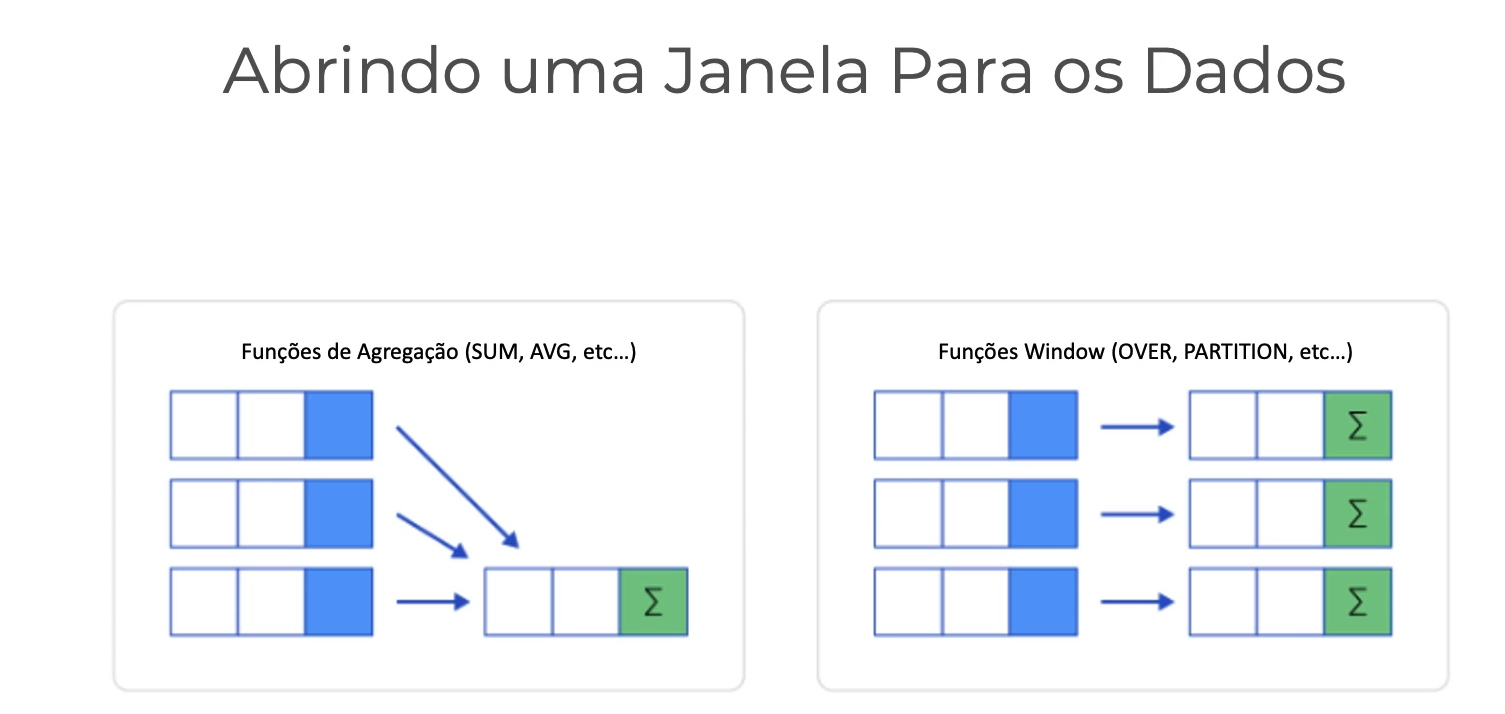

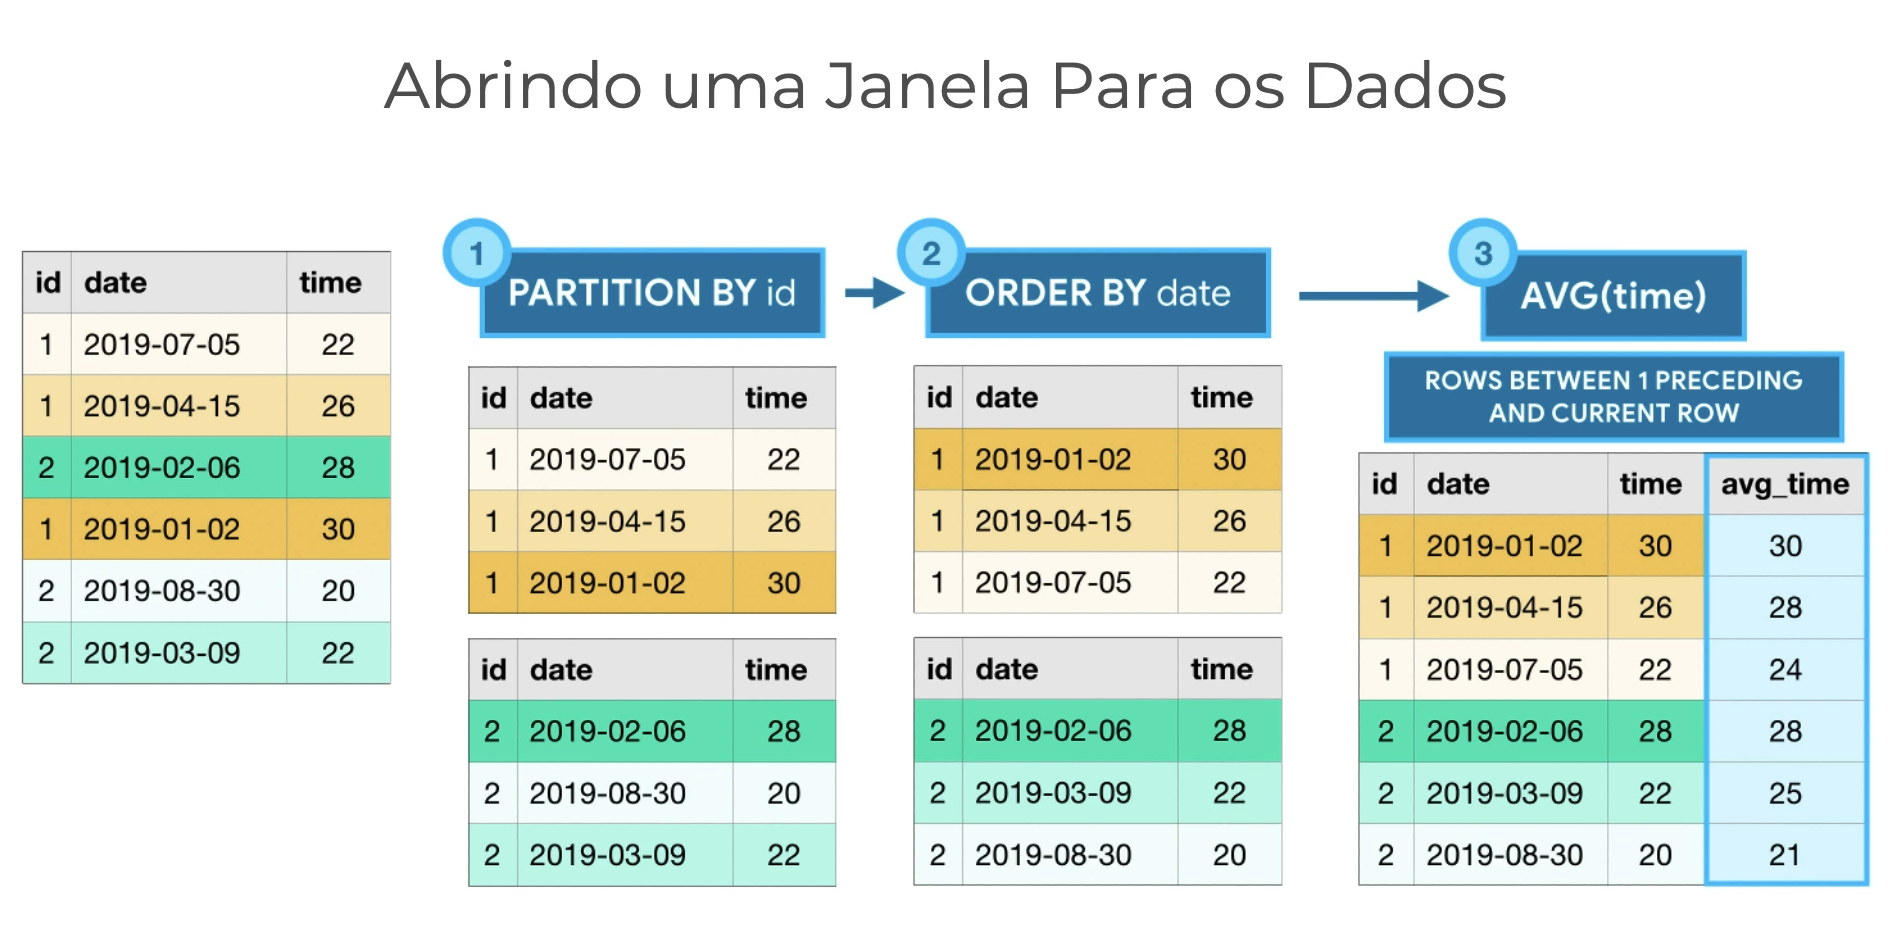

In [ ]:
create database dados_tempo;

In [ ]:
use dados_tempo;

In [ ]:
CREATE TABLE dados_tempo.TB_VENDAS (
    nome_funcionario VARCHAR(50) NOT NULL,
    ano_fiscal INT NOT NULL,
    valor_venda DECIMAL(14,2) NOT NULL,
    PRIMARY KEY(nome_funcionario,ano_fiscal)
);

In [ ]:
INSERT INTO dados_tempo.TB_VENDAS(nome_funcionario, ano_fiscal, valor_venda)
VALUES('Romario',2020,2000),
      ('Romario',2021,2500),
      ('Romario',2022,3000),
      ('Zico',2020,1500),
      ('Zico',2021,1000),
      ('Zico',2022,2000),
	('Pele',2020,2000),
      ('Pele',2021,1500),
      ('Pele',2022,2500);

In [ ]:
SELECT * FROM TB_VENDAS;

In [ ]:
SELECT SUM(valor_venda) AS total_vendas
FROM TB_VENDAS;

In [ ]:
SELECT ano_fiscal, SUM(valor_venda) AS total_vendas
FROM TB_VENDAS
GROUP BY ano_fiscal;

In [ ]:
-- Total de vendas por funcionario e por ano

SELECT nome_funcionario, ano_fiscal, SUM(valor_venda) AS total_vendas
FROM TB_VENDAS
GROUP BY nome_funcionario, ano_fiscal
ORDER BY ano_fiscal;

# Partition

In [ ]:
# Total de vendas por ano, por funcionário e total de vendas do ano
SELECT 
    ano_fiscal, 
    nome_funcionario,
    valor_venda,
    SUM(valor_venda) OVER (PARTITION BY ano_fiscal) total_vendas_ano
FROM TB_VENDAS
ORDER BY ano_fiscal;

In [ ]:
# Total de vendas por ano, por funcionário e total de vendas geral
SELECT 
    ano_fiscal, 
    nome_funcionario,
    valor_venda,
    SUM(valor_venda) OVER() total_vendas_geral
FROM TB_VENDAS
ORDER BY ano_fiscal;

In [ ]:
# Número de vendas por ano, por funcionário e número total de vendas em todos os anos
SELECT 
    ano_fiscal, 
    nome_funcionario,
    COUNT(*) num_vendas_ano,
    COUNT(*) OVER() num_vendas_geral
FROM TB_VENDAS
GROUP BY ano_fiscal, nome_funcionario
ORDER BY ano_fiscal;